
========== UCI Diabetes Dataset ==========
Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1 Score : 1.0000


C:\Users\pashv\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


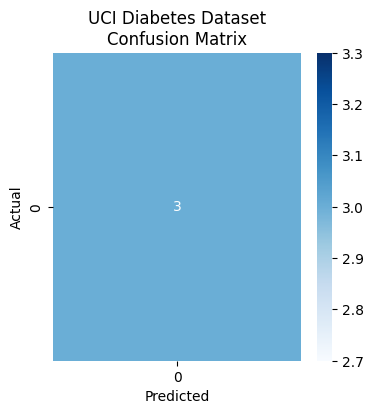


========== Pima Diabetes Dataset ==========
Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1 Score : 1.0000


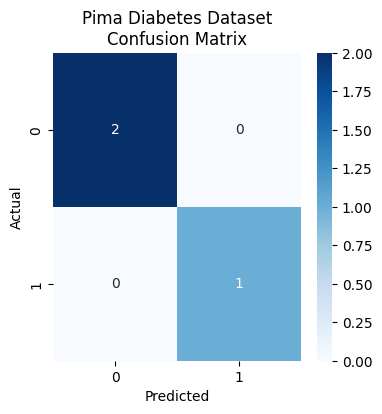

In [3]:
# Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

# ---------------------------------------------------
# Sample UCI Diabetes Dataset
# ---------------------------------------------------
uci_diabetes = pd.DataFrame({
    "Glucose":[148,85,183,89,137,116,78,115,197,125,99,168,145,110,132],
    "BloodPressure":[72,66,64,66,40,74,50,72,70,96,76,68,82,60,78],
    "BMI":[33.6,26.6,23.3,28.1,43.1,25.6,31.0,35.3,30.5,27.5,29.4,32.8,34.2,24.7,31.8],
    "Outcome":[1,0,1,0,1,0,0,0,1,1,0,1,1,0,1]
})

# ---------------------------------------------------
# Sample Pima Diabetes Dataset
# ---------------------------------------------------
pima_diabetes = pd.DataFrame({
    "Glucose":[120,140,110,95,160,180,130,145,155,100,135,170,150,115,125],
    "BloodPressure":[70,80,68,72,76,90,74,78,82,65,75,88,79,69,71],
    "BMI":[25.5,29.8,24.3,26.7,32.1,35.5,30.2,31.0,34.8,23.9,28.5,36.2,33.4,27.1,29.6],
    "Outcome":[0,1,0,0,1,1,0,1,1,0,0,1,1,0,0]
})

# Features and Target
features = ["Glucose", "BloodPressure", "BMI"]
target = "Outcome"

# ---------------------------------------------------
# Function for Logistic Regression
# ---------------------------------------------------
def logistic_analysis(df, dataset_name):

    X = df[features]
    y = df[target]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        random_state=42
    )

    model = LogisticRegression(max_iter=1000)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    print(f"\n========== {dataset_name} ==========")
    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")

    plt.figure(figsize=(4,4))
    sns.heatmap(
        confusion_matrix(y_test, y_pred),
        annot=True,
        fmt="d",
        cmap="Blues"
    )
    plt.title(f"{dataset_name}\nConfusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

# ---------------------------------------------------
# Run Analysis
# ---------------------------------------------------
logistic_analysis(uci_diabetes, "UCI Diabetes Dataset")
logistic_analysis(pima_diabetes, "Pima Diabetes Dataset")